In [ ]:
#@title Copyright 2023 Google LLC. Double-click here for license information.
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Colab 简介

机器学习速成课程使用 Colaboratory（Colab）完成所有编程练习。Colab 是 Google 对 [Jupyter Notebook](https://jupyter.org/) 的实现。有关 Colab 以及如何使用它的更多信息，请参阅 [Welcome to Colaboratory](https://research.google.com/colaboratory)。

# 线性回归
在这个 Colab 中，你将使用一个真实数据集来训练模型，预测美国伊利诺伊州芝加哥出租车行程的车费。

## 学习目标
完成本 Colab 后，你将能够：

  * 将 `.csv` 文件读取到 [pandas](https://developers.google.com/machine-learning/glossary/#pandas) DataFrame 中。
  * 使用 Python 可视化库探索一个[数据集](https://developers.google.com/machine-learning/glossary/#data_set)。
  * 尝试使用不同的[特征](https://developers.google.com/machine-learning/glossary/#feature)来构建线性回归模型。
  * 调整模型的[超参数](https://developers.google.com/machine-learning/glossary/#hyperparameter)。
  * 使用[均方根误差](https://developers.google.com/machine-learning/glossary/#root-mean-squared-error-rmse)和[损失曲线](https://developers.google.com/machine-learning/glossary/#loss-curve)比较不同训练实验。

## 数据集说明
[本练习使用的数据集](https://storage.mtls.cloud.google.com/mlcc-nextgen-internal/chicago_taxi_train.csv) 来自 [City of Chicago Taxi Trips dataset](https://data.cityofchicago.org/Transportation/Taxi-Trips/wrvz-psew)。本练习的数据是出租车行程数据的一个子集，重点关注 2022 年 5 月的两天时间段。


# 第 1 部分 - 环境设置练习


---


## 加载所需模块

本练习依赖多个 Python 库，用于数据处理、机器学习任务和数据可视化。

**操作说明**
1. 运行下面的 **Install required libraries** 代码单元。
1. 运行下面的 **Load dependencies** 代码单元。


In [ ]:
#@title 安装所需库

!pip install google-ml-edu==0.1.3 \
  keras~=3.8.0 \
  matplotlib~=3.10.0 \
  numpy~=2.0.0 \
  pandas~=2.2.0 \
  tensorflow~=2.18.0

print('\n\n所有依赖已成功安装。')


In [1]:
#@title 代码 - 加载依赖

# 数据处理
import numpy as np
import pandas as pd

# 机器学习
import keras
import ml_edu.experiment
import ml_edu.results

# 数据可视化
import plotly.express as px


## 加载数据集


下面的代码单元会加载数据集，并创建一个 pandas DataFrame。

你可以把 DataFrame 理解成带有行和列的电子表格。行表示一条条独立的数据样本，列表示每个样本对应的属性。


In [2]:
# @title
chicago_taxi_dataset = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")

## 更新 DataFrame

下面的代码单元会更新 DataFrame，只保留数据集中的指定列。

请注意，输出只展示了数据集的一小部分样本，但这些信息已经足够让你识别数据集中的特征，并查看几个样本的实际数据。


In [3]:
#@title 代码 - 读取数据集

# 更新 dataframe，只使用指定列。
training_df = chicago_taxi_dataset.loc[:, ('TRIP_MILES', 'TRIP_SECONDS', 'FARE', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE')]

print('数据集读取成功。')
print('总行数: {0}\n\n'.format(len(training_df.index)))
training_df.head(200)


数据集读取成功。
总行数: 31694




,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0
...,...,...,...,...,...,...
195,1.13,821,9.00,Blue Ribbon Taxi Association,Mobile,22.9
196,0.57,414,6.00,Flash Cab,Cash,0.0
197,1.22,886,9.00,City Service,Cash,0.0
198,1.68,1219,9.00,Sun Taxi,Mobile,23.0


# 第 2 部分 - 数据集探索


---


## 查看数据集统计信息

大多数机器学习项目中，很重要的一步是了解你的数据。在这一步中，你将使用 ``DataFrame.describe`` 方法查看数据集的描述性统计信息，并回答一些关于数据的重要问题。

**操作说明**
1. 运行 **View dataset statistics** 代码单元。
1. 查看输出，并回答以下问题：
  * 最大车费是多少？
  * 所有行程的平均距离是多少？
  * 数据集中有多少家出租车公司？
  * 最常见的付款方式是什么？
  * 是否有特征缺失数据？
1. 运行 **View answers to dataset statistics** 代码单元，检查你的答案。


你可能会注意到输出中有一些 `NaN`（not a number，非数字）值。在 Python 中处理数据时，如果某个计算结果无法得到，或者缺少相关信息，就可能出现这个值。例如，在出租车数据集中，`PAYMENT_TYPE` 和 `COMPANY` 是非数值的类别特征；对于类别特征，均值、最大值这类数值统计没有实际意义，因此输出会显示 `NaN`。


In [4]:
#@title 代码 - 查看数据集统计信息

print('总行数: {0}\n\n'.format(len(training_df.index)))
training_df.describe(include='all')


总行数: 31694




,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
count,31694.000000,31694.000000,31694.000000,31694,31694,31694.000000
unique,NaN,NaN,NaN,31,7,NaN
top,NaN,NaN,NaN,Flash Cab,Credit Card,NaN
freq,NaN,NaN,NaN,7887,14142,NaN
mean,8.289463,1319.796397,23.905210,NaN,NaN,12.965785
std,7.265672,928.932873,16.970022,NaN,NaN,15.517765
min,0.500000,60.000000,3.250000,NaN,NaN,0.000000
25%,1.720000,548.000000,9.000000,NaN,NaN,0.000000
50%,5.920000,1081.000000,18.750000,NaN,NaN,12.200000
75%,14.500000,1888.000000,38.750000,NaN,NaN,20.800000


In [5]:
#@title 双击或运行以查看数据集统计问题的答案

answer = '''
最大车费是多少？                         答案: $159.25
所有行程的平均距离是多少？               答案: 8.2895 英里
数据集中有多少家出租车公司？             答案: 31
最常见的付款方式是什么？                 答案: Credit Card
是否有特征缺失数据？                     答案: 否
'''

# 运行 DataFrame describe 方法后，你应该可以通过查看表格输出来找到
# 这些数据集问题的答案。
#
# 运行此代码单元可以验证你的答案。

# 最大车费是多少？
max_fare = training_df['FARE'].max()
print("最大车费是多少？                         答案: ${fare:.2f}".format(fare = max_fare))

# 所有行程的平均距离是多少？
mean_distance = training_df['TRIP_MILES'].mean()
print("所有行程的平均距离是多少？               答案: {mean:.4f} 英里".format(mean = mean_distance))

# 数据集中有多少家出租车公司？
num_unique_companies =  training_df['COMPANY'].nunique()
print("数据集中有多少家出租车公司？             答案: {number}".format(number = num_unique_companies))

# 最常见的付款方式是什么？
most_freq_payment_type = training_df['PAYMENT_TYPE'].value_counts().idxmax()
print("最常见的付款方式是什么？                 答案: {type}".format(type = most_freq_payment_type))

# 是否有特征缺失数据？
missing_values = training_df.isnull().sum().sum()
print("是否有特征缺失数据？                     答案:", "否" if missing_values == 0 else "是")


最大车费是多少？                         答案: $159.25
所有行程的平均距离是多少？               答案: 8.2895 英里
数据集中有多少家出租车公司？             答案: 31
最常见的付款方式是什么？                 答案: Credit Card
是否有特征缺失数据？                     答案: 否


## 生成相关矩阵

机器学习中的一个重要步骤，是判断哪些[特征](https://developers.google.com/machine-learning/glossary/#feature)与[标签](https://developers.google.com/machine-learning/glossary/#label)相关。如果你曾经乘坐过出租车，你的经验可能会告诉你，车费通常与行驶距离和行程时长有关。但是，有没有办法进一步了解这些特征与车费（标签）的相关程度呢？

在这一步中，你将使用**相关矩阵**来识别哪些特征值与标签有较好的相关性。相关系数含义如下：

  * **`1.0`**：完全正相关；也就是说，一个属性上升时，另一个属性也上升。
  * **`-1.0`**：完全负相关；也就是说，一个属性上升时，另一个属性下降。
  * **`0.0`**：无相关性；这两列[不是线性相关](https://en.wikipedia.org/wiki/Correlation_and_dependence#/media/File:Correlation_examples2.svg)。

一般来说，相关系数的绝对值越大，预测能力越强。

**操作说明**

1. 查看 **View correlation matrix** 代码单元中的代码。
1. 运行 **View correlation matrix** 代码单元，并检查输出。
1. **检查你的理解**，回答以下问题：
  * 哪个特征与标签 `FARE` 的相关性最强？
  * 哪个特征与标签 `FARE` 的相关性最弱？



In [6]:
#@title 代码 - 查看相关矩阵
training_df.corr(numeric_only = True)


,TRIP_MILES,TRIP_SECONDS,FARE,TIP_RATE
TRIP_MILES,1.000000,0.800855,0.975344,-0.049594
TRIP_SECONDS,0.800855,1.000000,0.830292,-0.084294
FARE,0.975344,0.830292,1.000000,-0.070979
TIP_RATE,-0.049594,-0.084294,-0.070979,1.000000


In [8]:
#@title 双击以查看相关矩阵问题的答案

# 哪个特征与标签 FARE 的相关性最强？
# ---------------------------------------------------------
answer = '''
与 FARE 相关性最强的特征是 TRIP_MILES。
正如你可能预期的那样，TRIP_MILES 看起来是训练模型时一个很好的起始特征。
另外，请注意 TRIP_SECONDS 与车费也有很强的相关性。
'''
print(answer)


# 哪个特征与标签 FARE 的相关性最弱？
# -----------------------------------------------------------
answer = '''与 FARE 相关性最弱的特征是 TIP_RATE。'''
print(answer)



与 FARE 相关性最强的特征是 TRIP_MILES。
正如你可能预期的那样，TRIP_MILES 看起来是训练模型时一个很好的起始特征。
另外，请注意 TRIP_SECONDS 与车费也有很强的相关性。

与 FARE 相关性最弱的特征是 TIP_RATE。


## 可视化数据集中的关系

有时，将数据集中各个特征之间的关系可视化会很有帮助；一种方法是使用成对图（pair plot）。**成对图**会生成一个成对图表网格，用来在同一位置查看每个特征与其他所有特征之间的关系。

**操作说明**
1. 运行 **View pair plot** 代码单元。


In [8]:
#@title 代码 - 查看成对图
px.scatter_matrix(training_df, dimensions=["FARE", "TRIP_MILES", "TRIP_SECONDS"])


# 第 3 部分 - 训练模型


---


## 定义构建和训练模型的函数

构建和训练模型所需的代码位于 **Define ML functions** 代码单元中。如果你想探索这部分代码，可以展开该代码单元查看。

**操作说明**
1. 运行 **Define ML functions** 代码单元。


In [9]:
#@title 代码 - 定义机器学习函数

def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
  """创建并编译一个简单的线性回归模型。"""
  # 描述模型的拓扑结构。
  # 一个简单线性回归模型的拓扑结构
  # 是单层中的单个节点。
  inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
  concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
  outputs = keras.layers.Dense(units=1)(concatenated_inputs)
  model = keras.Model(inputs=inputs, outputs=outputs)

  # 将模型拓扑结构编译成 Keras 可以高效执行的代码。
  # 配置训练过程，使模型的均方误差最小化。
  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
                loss="mean_squared_error",
                metrics=metrics)

  return model


def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
) -> ml_edu.experiment.Experiment:
  """通过向模型输入数据来训练模型。"""

  # 将特征和标签输入模型。
  # 模型会按照指定的 epoch 数进行训练。
  features = {name: dataset[name].values for name in settings.input_features}
  label = dataset[label_name].values
  history = model.fit(x=features,
                      y=label,
                      batch_size=settings.batch_size,
                      epochs=settings.number_epochs)

  return ml_edu.experiment.Experiment(
      name=experiment_name,
      settings=settings,
      model=model,
      epochs=history.epoch,
      metrics_history=pd.DataFrame(history.history),
  )

print("成功：线性回归函数定义完成。")


成功：线性回归函数定义完成。


## 使用一个特征训练模型

在这一步中，你将使用**单个特征**训练一个模型，用来预测车费。前面你已经看到，`TRIP_MILES`（距离）与 ``FARE`` 的相关性最强，所以我们先用 `TRIP_MILES` 作为第一次训练的特征。

**操作说明**

1. 运行 **Experiment 1** 代码单元，用一个特征构建模型。
1. 查看训练运行的输出。
1. 通过回答以下问题来**检查你的理解**：
  * 训练多少个 epoch 后模型收敛到最终状态？
  * 这个模型对样本数据的拟合效果如何？

训练过程中，你应该会在输出中看到均方根误差（RMSE）。RMSE 的单位与标签单位相同，也就是美元。换句话说，你可以使用 RMSE 判断预测车费平均来说与观测车费相差多少美元。


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step - loss: 264.3916 - rmse: 16.2601
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - loss: 91.0781 - rmse: 9.5435  
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - loss: 23.5567 - rmse: 4.8535
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step - loss: 17.6310 - rmse: 4.1989
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - loss: 16.3690 - rmse: 4.0459
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step - loss: 15.4369 - rmse: 3.9290
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - loss: 14.7903 - rmse: 3.8458
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - loss: 14.4007 - rmse: 3.7948
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - loss: 14.1991 - rmse: 3.7682
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step - loss: 14.1068 - rmse: 3.7559
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step - loss: 14.0665 - rmse: 3.7505
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - lo

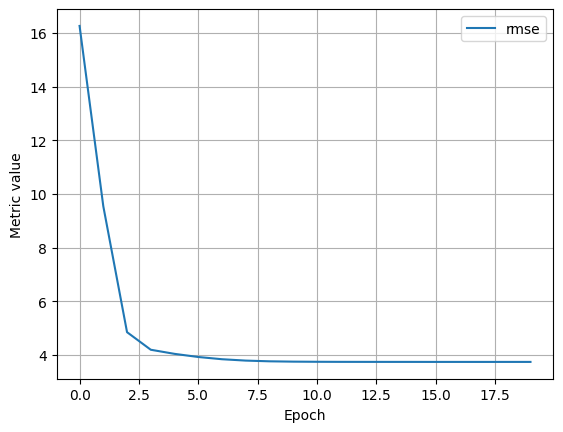

In [10]:
#@title 代码 - 实验 1

# 以下变量是超参数。
settings_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1 = create_model(settings_1, metrics)

experiment_1 = train_model('one_feature', model_1, training_df, 'FARE', settings_1)

ml_edu.results.plot_experiment_metrics(experiment_1, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_1, training_df, 'FARE')


In [11]:
#@title 双击以查看使用一个特征训练模型的答案

# 训练多少个 epoch 后模型收敛到最终状态？
# -----------------------------------------------------------------------------
answer = """
使用损失曲线查看训练过程中损失从哪里开始趋于平缓。

在这组超参数下：

  learning_rate = 0.001
  epochs = 20
  batch_size = 50

训练大约需要 5 个 epoch 才会收敛到最终模型。
"""
print(answer)

# 这个模型对样本数据的拟合效果如何？
# -----------------------------------------------------------------------------
answer = """
从模型图来看，该模型对样本数据的拟合效果相当不错。
"""
print(answer)



使用损失曲线查看训练过程中损失从哪里开始趋于平缓。

在这组超参数下：

  learning_rate = 0.001
  epochs = 20
  batch_size = 50

训练大约需要 5 个 epoch 才会收敛到最终模型。


从模型图来看，该模型对样本数据的拟合效果相当不错。



## 尝试不同的超参数

在机器学习中，通常需要运行多个实验来找到训练模型的最佳超参数组合。在这一步中，请逐一改变超参数，尝试下面这组实验：

* *实验 1：* 将学习率**增大**到 **``1.0``**（批量大小保持 ``50``）。
* *实验 2：* 将学习率**减小**到 **``0.0001``**（批量大小保持 ``50``）。
* *实验 3：* 将批量大小**增大**到 **``500``**（学习率保持 ``0.001``）。

**操作说明**
1. 根据实验要求，更新 **Experiment 2** 代码单元中的超参数值。
2. 运行 **Experiment 2** 代码单元。
3. 训练完成后，检查输出，并记录你在损失曲线或模型输出中看到的差异。
4. 对每个超参数实验重复步骤 1 - 3。
5. 通过回答以下问题来**检查你的理解**：
  * 提高学习率会如何影响你训练模型的能力？
  * 降低学习率会如何影响你训练模型的能力？
  * 改变批量大小是否会影响训练结果？



Epoch 1/10000
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - loss: 1933.1737 - rmse: 43.9679 
Epoch 2/10000
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 1926.4465 - rmse: 43.8913
Epoch 3/10000
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - loss: 1919.8802 - rmse: 43.8164
Epoch 4/10000
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - loss: 1913.3402 - rmse: 43.7417
Epoch 5/10000
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - loss: 1906.7682 - rmse: 43.6666
Epoch 6/10000
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - loss: 1900.2164 - rmse: 43.5915
Epoch 7/10000
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - loss: 1893.6901 - rmse: 43.5165
Epoch 8/10000
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - loss: 1887.2148 - rmse: 43.4421
Epoch 9/10000
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - loss: 1880.6753 - rmse: 43.3668
Epoch 10/10000
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step - loss: 1874.1780 - rmse: 43.2918
Epoch 11/10000
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - loss: 1867.6968 - rmse: 43.2169
Epoch 12/10000
64/

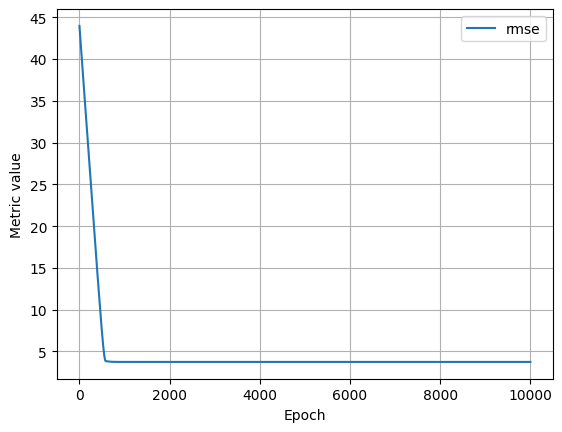

In [21]:
#@title 代码 - 实验 2

# 以下变量是超参数。
# TODO - 调整这些超参数，观察它们如何影响一次训练运行。
# settings_2 = ml_edu.experiment.ExperimentSettings(
#     learning_rate = 0.001,
#     number_epochs = 20,
#     batch_size = 50,
#     input_features = ['TRIP_MILES']
# )
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.0001,
    number_epochs = 10000,
    batch_size = 500,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature_hyper', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')


In [13]:
#@title 双击以查看超参数实验的答案

# 提高学习率会如何影响你训练模型的能力？
# -----------------------------------------------------------------------------
answer = """
当学习率过高时，损失曲线会来回跳动，并且看起来不会随着每次迭代逐步走向收敛。
另外，请注意预测模型对数据的拟合效果也不好。学习率过高时，通常很难训练出效果好的模型。
"""
print(answer)

# 降低学习率会如何影响你训练模型的能力？
# -----------------------------------------------------------------------------
answer = """
当学习率太小时，损失曲线可能需要更长时间才会收敛。
使用较小学习率时，损失曲线会缓慢下降，但不会出现明显的大幅下降或趋于平缓。
如果学习率较小，你可以增加 epoch 数，让模型最终收敛，但训练会花更长时间。
"""
print(answer)

# 改变批量大小是否会影响训练结果？
# -----------------------------------------------------------------------------
answer = """
增大批量大小会让每个 epoch 运行得更快，但和较小学习率类似，模型在只有 20 个 epoch 的情况下不会收敛。
如果你有时间，可以尝试增加 epoch 数，最终应该能看到模型收敛。
"""
print(answer)



当学习率过高时，损失曲线会来回跳动，并且看起来不会随着每次迭代逐步走向收敛。
另外，请注意预测模型对数据的拟合效果也不好。学习率过高时，通常很难训练出效果好的模型。


当学习率太小时，损失曲线可能需要更长时间才会收敛。
使用较小学习率时，损失曲线会缓慢下降，但不会出现明显的大幅下降或趋于平缓。
如果学习率较小，你可以增加 epoch 数，让模型最终收敛，但训练会花更长时间。


增大批量大小会让每个 epoch 运行得更快，但和较小学习率类似，模型在只有 20 个 epoch 的情况下不会收敛。
如果你有时间，可以尝试增加 epoch 数，最终应该能看到模型收敛。



## 使用两个特征训练模型

你使用 ``TOTAL_MILES`` 特征训练的模型已经表现出相当强的预测能力，但是否还能做得更好？在这一步中，请尝试使用两个特征 ``TRIP_MILES`` 和 ``TRIP_MINUTES`` 训练模型，看看是否能提升模型效果。你可能还记得，原始数据集中并不包含 ``TRIP_MINUTES`` 这个特征，但可以像下面代码中展示的那样，很容易从 ``TRIP_SECONDS`` 派生出这个特征。*

**操作说明**
1. 查看 **Experiment 3** 代码单元中的代码。
1. 运行 **Experiment 3** 代码单元。
1. 查看训练运行的输出，并回答以下问题：
  * 使用两个特征的模型是否比只使用单个特征的模型效果更好？
  * 使用 ``TRIP_SECONDS`` 代替 ``TRIP_MINUTES`` 是否会产生影响？
  * 你认为模型与芝加哥出租车行程真实车费计算方式有多接近？


请注意，特征与标签的散点图是一个三维（3-D）图。这个表示方式允许你同时可视化两个特征和标签。两个特征（TRIP_MILES 和 TRIP_MINUTES）位于 x 轴和 y 轴上，标签（FARE）位于 z 轴上。图中的圆点表示数据集中的单个样本，模型表示为一个曲面（平面）。对于这个 3-D 模型，如果训练效果很好，你会期望大多数样本点落在这个平面附近。这个 3-D 图是交互式的，因此你可以通过点击或拖动图表进一步探索数据。


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 721us/step - loss: 2389.5295 - rmse: 48.8828
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - loss: 699.9084 - rmse: 26.4558 
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step - loss: 92.3632 - rmse: 9.6106  
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step - loss: 42.1952 - rmse: 6.4958
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - loss: 24.9975 - rmse: 4.9997
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - loss: 16.2411 - rmse: 4.0300
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - loss: 13.1171 - rmse: 3.6218
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step - loss: 12.4174 - rmse: 3.5238
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - loss: 12.2292 - rmse: 3.4970
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - loss: 12.1526 - rmse: 3.4861
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 12.1257 - rmse: 3.4822
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step 

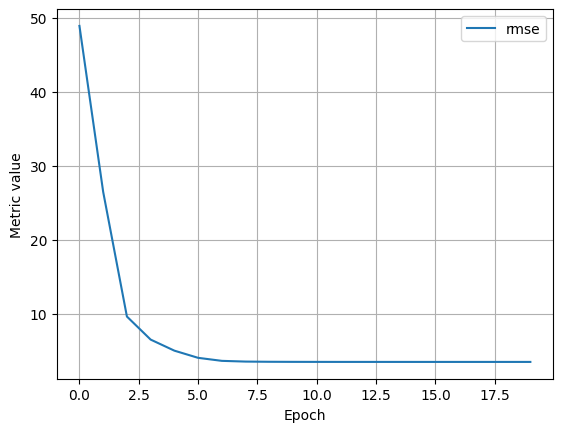

In [22]:
#@title 代码 - 实验 3

# 以下变量是超参数。
settings_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

training_df['TRIP_MINUTES'] = training_df['TRIP_SECONDS']/60

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3 = create_model(settings_3, metrics)

experiment_3 = train_model('two_features', model_3, training_df, 'FARE', settings_3)

ml_edu.results.plot_experiment_metrics(experiment_3, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_3, training_df, 'FARE')


In [23]:
#@title 双击以查看使用两个特征训练的答案

# 使用两个特征的模型是否比只使用单个特征的模型效果更好？
# -----------------------------------------------------------------------------
answer = """
要回答这个问题，请比较你自己训练运行中每个模型的 RMSE。
例如，如果只使用一个特征训练的模型 RMSE 为 3.7457，使用两个特征训练的模型 RMSE 为 3.4787，
这意味着平均来看，使用两个特征的模型预测结果比观测车费更接近约 0.27 美元。

"""
print(answer)

# 使用 TRIP_SECONDS 代替 TRIP_MINUTES 是否会产生影响？
# -----------------------------------------------------------------------------
answer = """
使用多个特征训练模型时，确保所有数值特征大致处于相同尺度非常重要。
在这个例子中，TRIP_SECONDS 和 TRIP_MILES 不满足这一条件。
TRIP_MILES 的均值是 8.3，而 TRIP_SECONDS 的均值是 1,320；两者相差两个数量级。
相比之下，TRIP_MINUTES 的均值是 22，比 TRIP_SECONDS（1,320）更接近 TRIP_MILES（8.3）的尺度。
当然，这不是训练前缩放数值的唯一方法，你会在另一个模块中学习更多相关内容。
"""
print(answer)

# 你认为模型与芝加哥出租车行程真实车费计算方式有多接近？
# -----------------------------------------------------------------------------
answer = """
实际上，芝加哥出租车会使用一个有文档记录的公式来计算车费。
对于一名乘客使用现金支付的情况，车费计算如下：

FARE = 2.25 * TRIP_MILES + 0.12 * TRIP_MINUTES + 3.25

通常在机器学习问题中，你并不知道“正确”的公式，但在这个例子中，你可以利用这项知识来评估模型。
查看你的模型输出（权重和偏差），判断它与真实车费计算公式匹配得如何。
你应该会发现模型大致接近这个公式。
"""
print(answer)



要回答这个问题，请比较你自己训练运行中每个模型的 RMSE。
例如，如果只使用一个特征训练的模型 RMSE 为 3.7457，使用两个特征训练的模型 RMSE 为 3.4787，
这意味着平均来看，使用两个特征的模型预测结果比观测车费更接近约 0.27 美元。



使用多个特征训练模型时，确保所有数值特征大致处于相同尺度非常重要。
在这个例子中，TRIP_SECONDS 和 TRIP_MILES 不满足这一条件。
TRIP_MILES 的均值是 8.3，而 TRIP_SECONDS 的均值是 1,320；两者相差两个数量级。
相比之下，TRIP_MINUTES 的均值是 22，比 TRIP_SECONDS（1,320）更接近 TRIP_MILES（8.3）的尺度。
当然，这不是训练前缩放数值的唯一方法，你会在另一个模块中学习更多相关内容。


实际上，芝加哥出租车会使用一个有文档记录的公式来计算车费。
对于一名乘客使用现金支付的情况，车费计算如下：

FARE = 2.25 * TRIP_MILES + 0.12 * TRIP_MINUTES + 3.25

通常在机器学习问题中，你并不知道“正确”的公式，但在这个例子中，你可以利用这项知识来评估模型。
查看你的模型输出（权重和偏差），判断它与真实车费计算公式匹配得如何。
你应该会发现模型大致接近这个公式。



## 比较实验


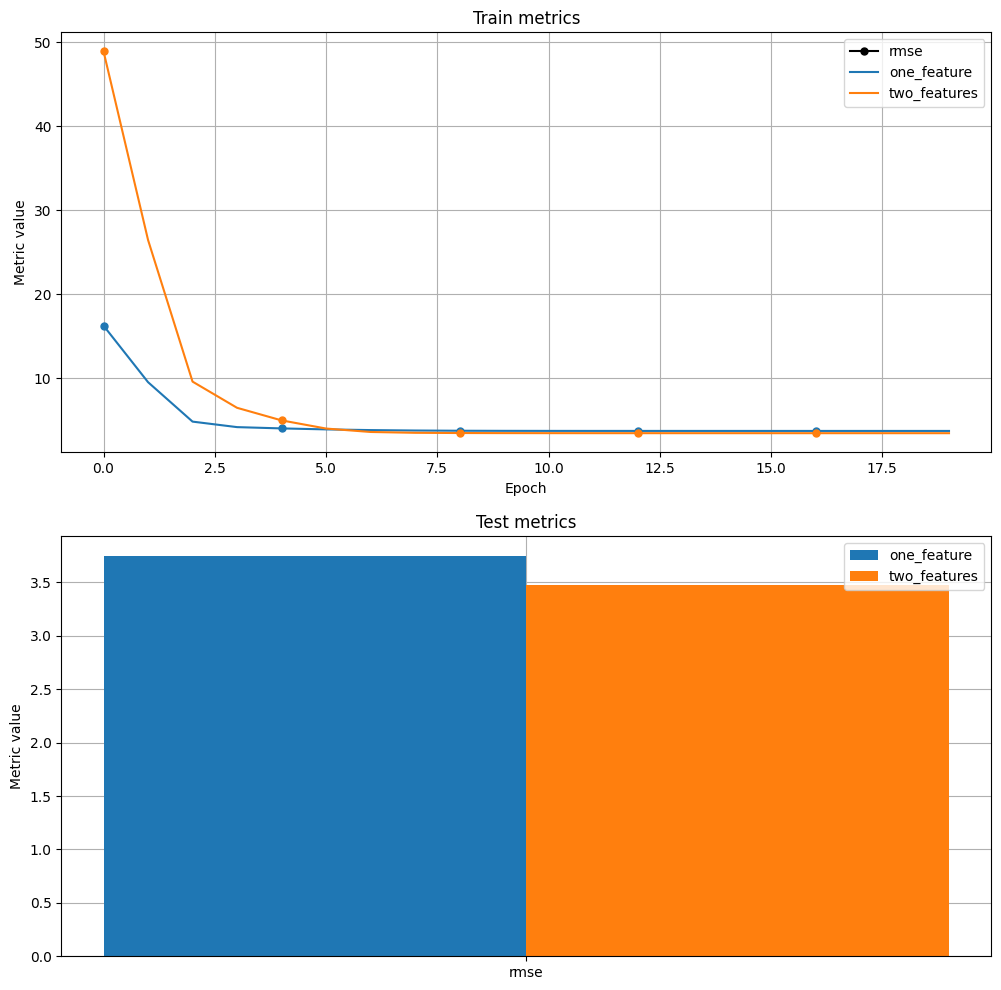

In [24]:
ml_edu.results.compare_experiment([experiment_1, experiment_3], ['rmse'], training_df, training_df['FARE'].values)

# 第 4 部分 - 验证模型


---


## 使用模型进行预测

现在你已经拥有一个训练好的模型，可以用它进行预测。在实际应用中，你应该在训练时未使用过的样本上进行预测。不过在本练习中，我们只会使用同一训练数据集的一个子集。在另一个 Colab 练习中，你将探索如何在训练时未使用过的样本上进行预测。

**操作说明**

1. 运行 **Define functions to make predictions** 代码单元。
1. 运行 **Make predictions** 代码单元。
1. 查看输出中的预测结果。
1. 通过回答以下问题来**检查你的理解**：
  * 预测值与标签值有多接近？换句话说，你的模型能否准确预测一次出租车行程的车费？


In [25]:
#@title 代码 - 定义用于预测的函数
def format_currency(x):
  return "${:.2f}".format(x)

def build_batch(df, batch_size):
  batch = df.sample(n=batch_size).copy()
  batch.set_index(np.arange(batch_size), inplace=True)
  return batch

def predict_fare(model, df, features, label, batch_size=50):
  batch = build_batch(df, batch_size)
  predicted_values = model.predict_on_batch(x={name: batch[name].values for name in features})

  data = {"PREDICTED_FARE": [], "OBSERVED_FARE": [], "L1_LOSS": [],
          features[0]: [], features[1]: []}
  for i in range(batch_size):
    predicted = predicted_values[i][0]
    observed = batch.at[i, label]
    data["PREDICTED_FARE"].append(format_currency(predicted))
    data["OBSERVED_FARE"].append(format_currency(observed))
    data["L1_LOSS"].append(format_currency(abs(observed - predicted)))
    data[features[0]].append(batch.at[i, features[0]])
    data[features[1]].append("{:.2f}".format(batch.at[i, features[1]]))

  output_df = pd.DataFrame(data)
  return output_df

def show_predictions(output):
  header = "-" * 80
  banner = header + "\n" + "|" + "预测结果".center(78) + "|" + "\n" + header
  print(banner)
  print(output)
  return


In [26]:
#@title 代码 - 进行预测

output = predict_fare(experiment_3.model, training_df, experiment_3.settings.input_features, 'FARE')
show_predictions(output)


--------------------------------------------------------------------------------
|                                     预测结果                                     |
--------------------------------------------------------------------------------
   PREDICTED_FARE OBSERVED_FARE L1_LOSS  TRIP_MILES TRIP_MINUTES
0          $23.67        $23.50   $0.17        8.41        19.15
1          $30.34        $31.50   $1.16        8.50        63.88
2           $9.61         $9.25   $0.36        2.11        10.40
3          $33.09        $31.50   $1.59       12.20        31.00
4          $31.67        $32.00   $0.33       12.28        20.12
5          $43.27        $43.75   $0.48       17.30        29.80
6          $37.90        $38.25   $0.35       15.17        22.57
7          $19.50        $19.00   $0.50        6.61        15.57
8          $39.67        $38.25   $1.42       13.99        51.32
9          $10.44         $9.75   $0.69        2.59         9.37
10         $18.23        $17.25   $0.98   

In [27]:
#@title 双击以查看验证模型的答案

# 预测值与标签值有多接近？
# -----------------------------------------------------------------------------
answer = """
基于随机抽样的一些样本来看，该模型预测出租车车费的效果似乎不错。
大多数预测值与观测值没有显著差异。
你可以查看 L1_LOSS = |observed - predicted| 这一列来判断这一点。
"""
print(answer)



基于随机抽样的一些样本来看，该模型预测出租车车费的效果似乎不错。
大多数预测值与观测值没有显著差异。
你可以查看 L1_LOSS = |observed - predicted| 这一列来判断这一点。

